In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action='ignore',category=DeprecationWarning)

# Lecture 11 #

## Lists

In [36]:
[1, 5, 'hello', 5.0]

[1, 5, 'hello', 5.0]

In [37]:
[1, 5, 'hello', 5.0, make_array(1,2,3)]

[1, 5, 'hello', 5.0, array([1, 2, 3])]

### Rows from lists

In [2]:
Table().with_columns('Numbers', [1, 2, 3])

Numbers
1
2
3


In [3]:
drinks = Table(['Drink', 'Cafe', 'Price'])
drinks

Drink,Cafe,Price


In [4]:
drinks = drinks.with_rows([
    ['Milk Tea', 'Asha', 5.5],
    ['Espresso', 'Strada',  1.75],
    ['Latte',    'Strada',  3.25],
    ['Espresso', "FSM",   2]
])
drinks

Drink,Cafe,Price
Milk Tea,Asha,5.5
Espresso,Strada,1.75
Latte,Strada,3.25
Espresso,FSM,2


## Tables: Grouping by One Column ##

The group command can combine similar entries and find counts or determine other various attributes of the data.

In [27]:
cones = Table.read_table('cones.csv').drop('Color')
cones

Flavor,Price
strawberry,3.55
chocolate,4.75
chocolate,5.25
strawberry,5.25
chocolate,5.25
bubblegum,4.75


In [30]:
# Finds the counts of each Flavor
cones.group('Flavor')

Flavor,count
bubblegum,1
chocolate,3
strawberry,2


In [31]:
# Finds the average price for each flavor
cones.group('Flavor', np.average)

Flavor,Price average
bubblegum,4.75
chocolate,5.08333
strawberry,4.4


In [32]:
# Finds the minimum price for each flavor. 
cones.group('Flavor', np.min)

Flavor,Price min
bubblegum,4.75
chocolate,4.75
strawberry,3.55


## Grouping By One Column: Welcome Survey ##

In [30]:
survey = Table.read_table('welcome_survey_sp22.csv')
survey.show(3)

Year,Extroversion,Number of textees,Hours of sleep,Handedness,Pant leg,Sleep position,Pets,Piercings
Second,5,5,8,Left-handed,Left leg in first,On your left side,Ants,0
Fourth,2,3,7,Right-handed,Left leg in first,On your left side,"Beetles, Centipedes, Scorpions",0
First,3,4,8,Right-handed,Right leg in first,On your back,Bird,0


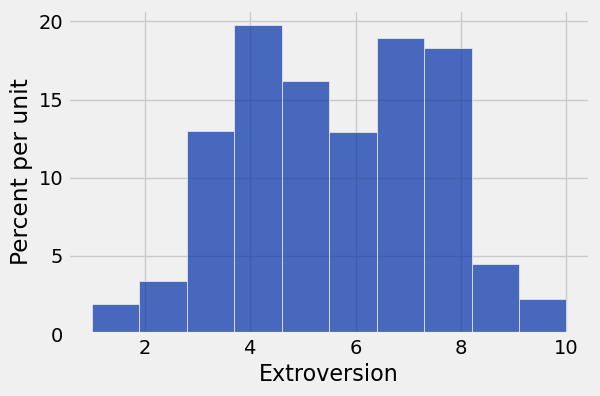

In [31]:
survey.hist('Extroversion')

In [32]:
by_extra = survey.group('Extroversion', np.average)
by_extra

Extroversion,Year average,Number of textees average,Hours of sleep average,Handedness average,Pant leg average,Sleep position average,Pets average,Piercings average
1,,2.08696,7.32609,,,,,0.478261
2,,3.21951,7.30488,,,,,0.95122
3,,4.71338,7.17516,,,,,1.57962
4,,4.96653,7.25941,,,,,1.7113
5,,5.39796,7.06888,,,,,1.45408
6,,5.8141,7.125,,,,,1.83974
7,,8.15721,7.04367,,,,,2.06987
8,,7.95475,7.07692,,,,,2
9,,10.7778,7.15741,,,,,2.88889
10,,13.037,7.16667,,,,,1.92593


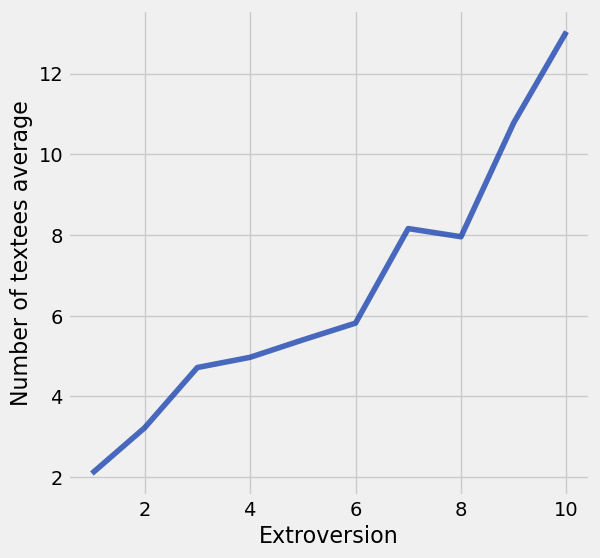

In [33]:
by_extra.plot('Extroversion', 'Number of textees average')

## Group by one column

In [5]:
survey = Table.read_table('welcome_survey_sp22.csv')
survey.show(3)

Year,Extroversion,Number of textees,Hours of sleep,Handedness,Pant leg,Sleep position,Pets,Piercings
Second,5,5,8,Left-handed,Left leg in first,On your left side,Ants,0
Fourth,2,3,7,Right-handed,Left leg in first,On your left side,"Beetles, Centipedes, Scorpions",0
First,3,4,8,Right-handed,Right leg in first,On your back,Bird,0


In [6]:
survey.group("Year")

Year,count
Fifth or above,18
First,577
First year In Master's Degree,1
Fourth,96
"I dont understand this question, I'm a first year but se ...",1
Junior Transfer,1
Not an undergrad,3
Second,419
Third,227


In [7]:
(survey
 .select("Year", "Hours of sleep")
 .group(0, np.average)
 .take(1, 7, 8, 3))

Year,Hours of sleep average
First,7.19757
Second,7.1778
Third,6.96696
Fourth,6.92188


## Cross-classification: grouping by two columns

In [8]:
survey.group(['Handedness', 'Sleep position']).show()

Handedness,Sleep position,count
Both,On your back,2
Both,On your left side,1
Both,On your right side,3
Both,On your stomach,3
Left-handed,On your back,15
Left-handed,On your left side,30
Left-handed,On your right side,31
Left-handed,On your stomach,17
Right-handed,On your back,299
Right-handed,On your left side,315


In [9]:
survey.group(['Handedness', 'Sleep position'],
             np.average).show()

Handedness,Sleep position,Year average,Extroversion average,Number of textees average,Hours of sleep average,Pant leg average,Pets average,Piercings average
Both,On your back,,7,6,5,,,4.5
Both,On your left side,,7,10,6,,,0
Both,On your right side,,7.66667,7.33333,8.16667,,,2
Both,On your stomach,,6,7,8.33333,,,0
Left-handed,On your back,,4.93333,5.6,7.06667,,,2.26667
Left-handed,On your left side,,5.76667,6.13333,6.96667,,,1.8
Left-handed,On your right side,,6.25806,7.3871,7.04839,,,1.3871
Left-handed,On your stomach,,6.17647,7.11765,7.5,,,1.70588
Right-handed,On your back,,5.48161,5.75251,7.11538,,,1.34114
Right-handed,On your left side,,5.55556,6.70476,7.11905,,,1.76825


## Pivot Tables

In [10]:
survey.group(['Sleep position', 'Handedness'])

Sleep position,Handedness,count
On your back,Both,2
On your back,Left-handed,15
On your back,Right-handed,299
On your left side,Both,1
On your left side,Left-handed,30
On your left side,Right-handed,315
On your right side,Both,3
On your right side,Left-handed,31
On your right side,Right-handed,451
On your stomach,Both,3


In [11]:
survey.pivot('Sleep position', 'Handedness')

Handedness,On your back,On your left side,On your right side,On your stomach
Both,2,1,3,3
Left-handed,15,30,31,17
Right-handed,299,315,451,176


In [12]:
survey.pivot('Sleep position', 
             'Handedness', 
             values='Hours of sleep', 
             collect=np.average)

Handedness,On your back,On your left side,On your right side,On your stomach
Both,5,6,8.16667,8.33333
Left-handed,7.06667,6.96667,7.04839,7.5
Right-handed,7.11538,7.11905,7.11863,7.25284


## Discussion Questions ##

In [13]:
# From the CORGIS Dataset Project
# By Austin Cory Bart acbart@vt.edu
# Version 2.0.0, created 3/22/2016
# https://corgis-edu.github.io/corgis/csv/skyscrapers/

sky = Table.read_table('skyscrapers.csv')
sky = (sky.with_column('age', 2022 - sky.column('completed'))
          .drop('completed'))
sky.show(3)

name,material,city,height,age
One World Trade Center,mixed/composite,New York City,541.3,8
Willis Tower,steel,Chicago,442.14,48
432 Park Avenue,concrete,New York City,425.5,7


In [14]:
# 1. For each city, what’s the tallest building for each material?

sky_p = sky.pivot('material', 
             'city', 
             values='height', 
             collect=np.max)
sky_p





city,concrete,mixed/composite,steel
Atlanta,264.25,311.8,169.47
Austin,208.15,0,93.6
Baltimore,161.24,0,155.15
Boston,121.92,139,240.79
Charlotte,265.48,239.7,179.23
Chicago,423.22,306.94,442.14
Cincinnati,125,202.69,175
Cleveland,125,288.65,215.8
Columbus,79.25,0,169.3
Dallas,176.48,280.72,270.06


In [15]:
# 2. For each city, what’s the height difference between the tallest 
#    steel building and the tallest concrete building?

sky_p = sky_p.with_column('difference', sky_p.column('steel') - sky_p.column('concrete'))
sky_p







city,concrete,mixed/composite,steel,difference
Atlanta,264.25,311.8,169.47,-94.78
Austin,208.15,0,93.6,-114.55
Baltimore,161.24,0,155.15,-6.09001
Boston,121.92,139,240.79,118.87
Charlotte,265.48,239.7,179.23,-86.25
Chicago,423.22,306.94,442.14,18.92
Cincinnati,125,202.69,175,50
Cleveland,125,288.65,215.8,90.8
Columbus,79.25,0,169.3,90.05
Dallas,176.48,280.72,270.06,93.58


Don't read ahead until you try the challenge questions yourself first!

In [18]:
sky.select('material', 'city', 'height').group(['city', 'material'], collect=max)

city,material,height max
Atlanta,concrete,264.25
Atlanta,mixed/composite,311.8
Atlanta,steel,169.47
Austin,concrete,208.15
Austin,steel,93.6
Baltimore,concrete,161.24
Baltimore,steel,155.15
Boston,concrete,121.92
Boston,mixed/composite,139
Boston,steel,240.79


In [19]:
sky_p = sky.pivot('material', 'city', values='height', collect=max)
sky_p.show()

city,concrete,mixed/composite,steel
Atlanta,264.25,311.8,169.47
Austin,208.15,0,93.6
Baltimore,161.24,0,155.15
Boston,121.92,139,240.79
Charlotte,265.48,239.7,179.23
Chicago,423.22,306.94,442.14
Cincinnati,125,202.69,175
Cleveland,125,288.65,215.8
Columbus,79.25,0,169.3
Dallas,176.48,280.72,270.06


In [20]:
sky_p = sky_p.with_column(
    'difference', 
    abs(sky_p.column('steel') - sky_p.column('concrete'))
)
sky_p

city,concrete,mixed/composite,steel,difference
Atlanta,264.25,311.8,169.47,94.78
Austin,208.15,0,93.6,114.55
Baltimore,161.24,0,155.15,6.09001
Boston,121.92,139,240.79,118.87
Charlotte,265.48,239.7,179.23,86.25
Chicago,423.22,306.94,442.14,18.92
Cincinnati,125,202.69,175,50
Cleveland,125,288.65,215.8,90.8
Columbus,79.25,0,169.3,90.05
Dallas,176.48,280.72,270.06,93.58


In [21]:
sky_p.sort('difference', True)

city,concrete,mixed/composite,steel,difference
Sunny Isles Beach,196,0,0,196
Las Vegas,350.22,195.68,164.6,185.62
Miami Beach,170.39,0,0,170.39
Pittsburgh,89.3,172,256.34,167.04
Los Angeles,145.7,118.26,310.29,164.59
Philadelphia,157.89,296.73,288.04,130.15
Boston,121.92,139,240.79,118.87
Austin,208.15,0,93.6,114.55
Seattle,138.69,284.38,235.31,96.62
Atlanta,264.25,311.8,169.47,94.78


In [26]:
# 3. Generate a table of the names of the oldest buildings for each 
#    material for each city:

# Hint: You can use sort to find the name of the oldest building in the dataset
sky.sort('age', descending=True).column('name').item(0)

def oldest_building(s):
    return s.item(0)

(sky
  .sort('age', descending=True)
  .pivot('material', 'city', 'name', collect=oldest_building)
)


city,concrete,mixed/composite,steel
Atlanta,Westin Peachtree Plaza,One Atlantic Center,FlatironCity
Austin,One American Center,,University of Texas Tower
Baltimore,Charles Towers North Apartments,,Emerson Tower
Boston,Harbor Towers I,Ellison Building,Marriott's Custom House
Charlotte,Bank of America Corporate Center,Hearst Tower,Midtown Plaza
Chicago,The Powhatan,American Furniture Mart,The Rookery
Cincinnati,Kroger Building,Great American Tower at Queen City Square,PNC Tower
Cleveland,National City Center,55 Public Square,Huntington Bank Building
Columbus,Key Bank Building,,Leveque Tower
Dallas,Reunion Tower,Bank of America Plaza,Three AT&T Plaza


(No peeking! A solution appears below.)

In [27]:
def first(s):
    "Return the first element in an array."
    return s.item(0)

(sky
 .sort('age', descending=True)
 .pivot('material', 'city', 'name', first)
).where('city', 'San Francisco')

city,concrete,mixed/composite,steel
San Francisco,Coit Tower,Transamerica Pyramid,Ferry Building


## Joins ##

In [28]:
drinks

Drink,Cafe,Price
Milk Tea,Asha,5.5
Espresso,Strada,1.75
Latte,Strada,3.25
Espresso,FSM,2


In [29]:
discounts = Table().with_columns(
    'Coupon % off', make_array(10, 25, 5),
    'Location', make_array('Asha', 'Strada', 'Asha')
)
discounts

Coupon % off,Location
10,Asha
25,Strada
5,Asha


In [30]:
combined = drinks.join('Cafe', discounts, 'Location')
combined

Cafe,Drink,Price,Coupon % off
Asha,Milk Tea,5.5,10
Asha,Milk Tea,5.5,5
Strada,Espresso,1.75,25
Strada,Latte,3.25,25


In [31]:
discounted_frac = 1 - combined.column('Coupon % off') / 100
combined.with_column(
    'Discounted Price', 
    combined.column('Price') * discounted_frac
)

Cafe,Drink,Price,Coupon % off,Discounted Price
Asha,Milk Tea,5.5,10,4.95
Asha,Milk Tea,5.5,5,5.225
Strada,Espresso,1.75,25,1.3125
Strada,Latte,3.25,25,2.4375


In [32]:
drinks.join('Cafe', drinks, 'Cafe')

Cafe,Drink,Price,Drink_2,Price_2
Asha,Milk Tea,5.5,Milk Tea,5.5
FSM,Espresso,2,Espresso,2
Strada,Espresso,1.75,Espresso,1.75
Strada,Espresso,1.75,Latte,3.25
Strada,Latte,3.25,Espresso,1.75
Strada,Latte,3.25,Latte,3.25
